# 01 — Análise Exploratória do Dataset Spotify
**Projeto:** Técnicas de Indexação e Ranking em Busca de Músicas  
**Parte:** 1 — Recuperação Clássica (BM25)  
**Objetivo:** Entender a estrutura do dataset, identificar problemas de qualidade e documentar as colunas que serão usadas nas Partes 1, 2 e 3.

---

## 0. Imports e configuração

In [1]:
import warnings
from collections import Counter
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# Estilo dos gráficos
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (12, 5)

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


## 1. Carregamento do dataset

O dataset do Kaggle (`lordpatil/spotify-metadata-by-annas-archive`) vem como vários parquets normalizados. Aqui montamos uma **visão plana** juntando tracks + artistas + álbuns + audio features via DuckDB.

> **Pré-requisito:** `data/spotify-metadata/` já precisa estar populado. Se ainda não estiver, rode `./scripts/download_spotify_metadata.sh --truncated` (padrão, ~344 MB) ou `--full` (Kaggle, ~5.5 GB).

In [2]:
# Caminhos base para os parquets do dataset
DATASET_DIR = Path("../data/spotify-metadata")
CLEAN_DIR = DATASET_DIR / "spotify_clean_parquet"
AUDIO_DIR = DATASET_DIR / "spotify_clean_audio_features_parquet"

if not CLEAN_DIR.exists():
    raise FileNotFoundError(
        f"{DATASET_DIR} vazia ou inexistente. "
        "Rode `./scripts/download_spotify_metadata.sh --truncated` "
        "(ou `--full`) antes de abrir o notebook."
    )

con = duckdb.connect()
query = f"""
    SELECT
        t.id              AS track_id,
        t.name            AS track_name,
        t.popularity,
        t.duration_ms,
        t.explicit,
        alb.name          AS album_name,
        alb.release_date,
        ar.name           AS artist_name,
        g.genre,
        CAST(af.acousticness     AS DOUBLE)  AS acousticness,
        CAST(af.danceability     AS DOUBLE)  AS danceability,
        CAST(af.energy           AS DOUBLE)  AS energy,
        CAST(af.valence          AS DOUBLE)  AS valence,
        CAST(af.speechiness      AS DOUBLE)  AS speechiness,
        CAST(af.instrumentalness AS DOUBLE)  AS instrumentalness,
        CAST(af.liveness         AS DOUBLE)  AS liveness,
        CAST(af.tempo            AS DOUBLE)  AS tempo,
        CAST(af.loudness         AS DOUBLE)  AS loudness,
        CAST(af.key              AS INTEGER) AS key,
        CAST(af.mode             AS INTEGER) AS mode,
        CAST(af.time_signature   AS INTEGER) AS time_signature
    FROM read_parquet('{CLEAN_DIR}/tracks.parquet') t
    LEFT JOIN (
        SELECT track_rowid, MIN(artist_rowid) AS artist_rowid
        FROM read_parquet('{CLEAN_DIR}/track_artists.parquet')
        GROUP BY track_rowid
    ) ta ON ta.track_rowid = t.rowid
    LEFT JOIN read_parquet('{CLEAN_DIR}/artists.parquet') ar
        ON ar.rowid = ta.artist_rowid
    LEFT JOIN read_parquet('{CLEAN_DIR}/albums.parquet') alb
        ON alb.rowid = t.album_rowid
    LEFT JOIN read_parquet('{AUDIO_DIR}/track_audio_features.parquet') af
        ON af.track_id = t.id
    LEFT JOIN (
        SELECT artist_rowid, MIN(genre) AS genre
        FROM read_parquet('{CLEAN_DIR}/artist_genres.parquet')
        GROUP BY artist_rowid
    ) g ON g.artist_rowid = ta.artist_rowid
"""
df = con.execute(query).fetchdf()

print(f"Dataset carregado: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
df.head(3)

Dataset carregado: 593,352 linhas x 21 colunas


,track_id,track_name,popularity,duration_ms,explicit,album_name,release_date,artist_name,genre,acousticness,...,energy,valence,speechiness,instrumentalness,liveness,tempo,loudness,key,mode,time_signature
0,531j0eSWy7hRFZnmJxA8n9,Old Orleans,3,129541,0,Rumble Jam - Big Band and Jazz Themes,2022-10-28,Gregory Cotti,big band,0.017,...,0.695,0.604,0.1610,0.00816,0.0470,208.144,-6.610,10,0,4
1,07NcviPFM0XqQ5YT272CIw,Janice Hartman,0,68493,0,Dark Atmospheres 13,2012-04-23,William Ashford,choral,0.953,...,0.105,0.175,0.0348,0.74300,0.1120,53.973,-17.222,2,0,3
2,78D89zgeBaAeVqJLJ4OBtS,Pitbull Perspective v2 - FullMix,0,81829,0,Ethnic Drama 11,2012-04-23,William Ashford,choral,0.394,...,0.341,0.324,0.0587,0.77600,0.0733,150.017,-15.767,8,0,4


## 2. Visão geral da estrutura

In [3]:
# Tipos de dados e contagem de nulos
info = pd.DataFrame(
    {
        "dtype": df.dtypes,
        "nulos": df.isnull().sum(),
        "nulos_%": (df.isnull().sum() / len(df) * 100).round(2),
        "únicos": df.nunique(),
        "exemplo": df.iloc[0],
    }
)
info

,dtype,nulos,nulos_%,únicos,exemplo
track_id,str,0,0.00,593352,531j0eSWy7hRFZnmJxA8n9
track_name,str,0,0.00,428012,Old Orleans
popularity,int64,0,0.00,99,3
duration_ms,int64,0,0.00,181582,129541
explicit,int64,0,0.00,2,0
album_name,str,0,0.00,318380,Rumble Jam - Big Band and Jazz Themes
release_date,str,0,0.00,15282,2022-10-28
artist_name,str,0,0.00,190621,Gregory Cotti
genre,str,243901,41.11,698,big band
acousticness,float64,24583,4.14,5385,0.017


In [4]:
# Identificar colunas por categoria
TEXT_COLS = [
    c
    for c in ["track_name", "artist_name", "album_name", "genre", "track_genre"]
    if c in df.columns
]
AUDIO_COLS = [
    c
    for c in [
        "acousticness",
        "danceability",
        "energy",
        "valence",
        "speechiness",
        "instrumentalness",
        "liveness",
    ]
    if c in df.columns
]
NUMERIC_COLS = [
    c
    for c in [
        "tempo",
        "loudness",
        "duration_ms",
        "popularity",
        "key",
        "mode",
        "time_signature",
    ]
    if c in df.columns
]

print("Colunas textuais  :", TEXT_COLS)
print("Atributos de áudio:", AUDIO_COLS)
print("Outros numéricos  :", NUMERIC_COLS)

Colunas textuais  : ['track_name', 'artist_name', 'album_name', 'genre']
Atributos de áudio: ['acousticness', 'danceability', 'energy', 'valence', 'speechiness', 'instrumentalness', 'liveness']
Outros numéricos  : ['tempo', 'loudness', 'duration_ms', 'popularity', 'key', 'mode', 'time_signature']


## 3. Duplicatas

In [5]:
n_dup = df.duplicated().sum()
print(f"Linhas duplicadas (100% idênticas): {n_dup:,}  ({n_dup / len(df) * 100:.2f}%)")

# Duplicatas por track_name + artist_name (mesma música, metadados repetidos)
key_cols = [c for c in ["track_name", "artist_name"] if c in df.columns]
if key_cols:
    n_dup_key = df.duplicated(subset=key_cols).sum()
    label = " + ".join(key_cols)
    print(f"Duplicatas por ({label}): {n_dup_key:,} ({n_dup_key / len(df) * 100:.2f}%)")

Linhas duplicadas (100% idênticas): 0  (0.00%)
Duplicatas por (track_name + artist_name): 54,102 (9.12%)


## 4. Análise das colunas textuais

In [6]:
# Comprimento médio dos campos textuais
for col in TEXT_COLS:
    lengths = df[col].dropna().astype(str).str.len()
    nulls = df[col].isnull().sum()
    print(f"{col:20s} | média: {lengths.mean():.1f} chars | max: {lengths.max()} | nulos: {nulls}")

track_name           | média: 18.3 chars | max: 326 | nulos: 0
artist_name          | média: 11.4 chars | max: 144 | nulos: 0
album_name           | média: 20.7 chars | max: 306 | nulos: 0
genre                | média: 9.1 chars | max: 27 | nulos: 243901


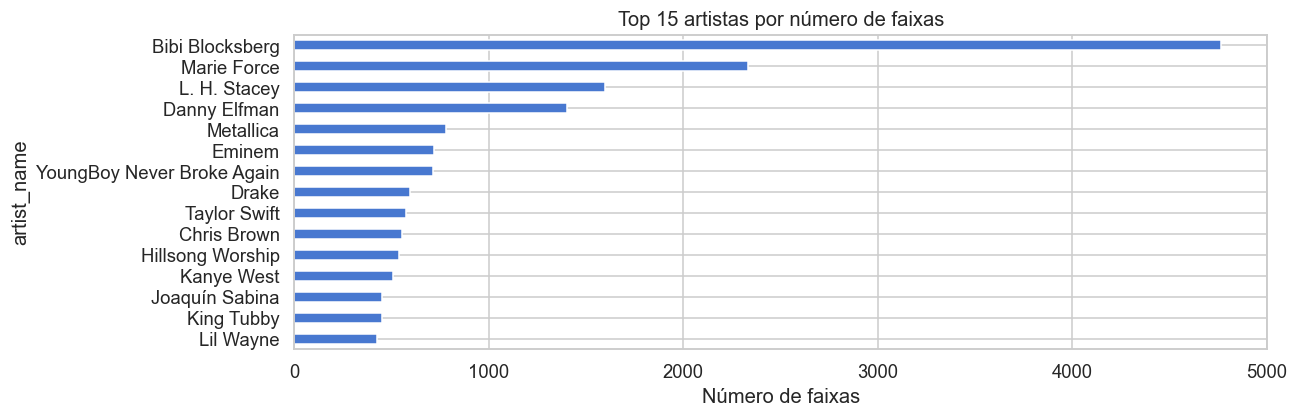

In [7]:
# Top 15 artistas mais frequentes
if "artist_name" in df.columns:
    top_artists = df["artist_name"].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(12, 4))
    top_artists.plot(kind="barh", ax=ax, color=sns.color_palette("muted")[0])
    ax.invert_yaxis()
    ax.set_title("Top 15 artistas por número de faixas")
    ax.set_xlabel("Número de faixas")
    plt.tight_layout()
    plt.show()

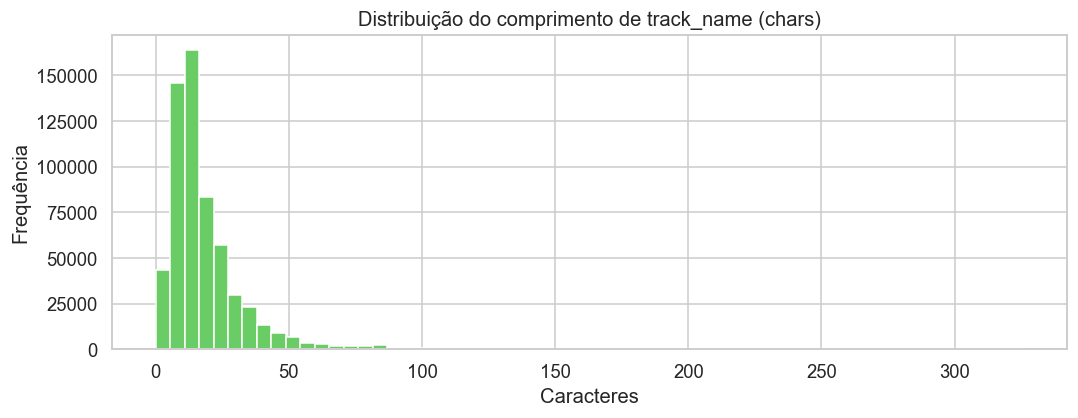

Mediana: 14 chars | P95: 45 chars


In [8]:
# Distribuição de comprimento do nome da faixa
if "track_name" in df.columns:
    track_len = df["track_name"].dropna().astype(str).str.len()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(track_len, bins=60, color=sns.color_palette("muted")[2], edgecolor="white")
    ax.set_title("Distribuição do comprimento de track_name (chars)")
    ax.set_xlabel("Caracteres")
    ax.set_ylabel("Frequência")
    plt.tight_layout()
    plt.show()
    print(f"Mediana: {track_len.median():.0f} chars | P95: {track_len.quantile(0.95):.0f} chars")

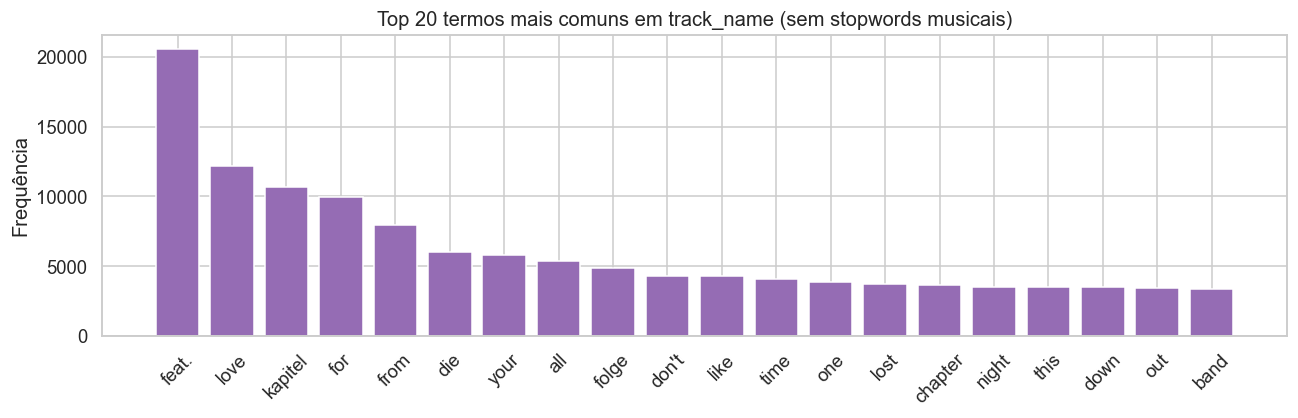

In [9]:
# Termos mais comuns em track_name (pré-processamento superficial)
if "track_name" in df.columns:
    STOPWORDS_MUSICA = {
        "feat",
        "ft",
        "remix",
        "remaster",
        "remastered",
        "version",
        "live",
        "edit",
        "mix",
        "radio",
        "original",
        "the",
        "a",
        "an",
        "and",
        "of",
        "in",
        "is",
        "it",
        "to",
        "you",
        "i",
        "my",
        "me",
        "with",
        "on",
    }

    all_tokens = []
    for name in df["track_name"].dropna().astype(str):
        tokens = [t.lower().strip("()[]- ") for t in name.split()]
        all_tokens.extend([t for t in tokens if t and t not in STOPWORDS_MUSICA and len(t) > 2])

    top_tokens = Counter(all_tokens).most_common(20)

    if top_tokens:
        words, counts = zip(*top_tokens, strict=True)

        fig, ax = plt.subplots(figsize=(12, 4))
        ax.bar(words, counts, color=sns.color_palette("muted")[4])
        ax.set_title("Top 20 termos mais comuns em track_name (sem stopwords musicais)")
        ax.set_ylabel("Frequência")
        ax.tick_params(axis="x", rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("Nenhum token relevante encontrado em track_name.")

## 5. Análise dos atributos de áudio

In [10]:
# Estatísticas descritivas dos atributos de áudio
df[AUDIO_COLS].describe().round(3)

,acousticness,danceability,energy,valence,speechiness,instrumentalness,liveness
count,568769.000,568769.000,568769.000,568769.000,568769.000,568769.000,568769.000
mean,0.310,0.578,0.601,0.454,0.126,0.199,0.200
std,0.330,0.185,0.259,0.258,0.174,0.342,0.167
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.019,0.460,0.423,0.241,0.038,0.000,0.099
50%,0.166,0.600,0.634,0.440,0.056,0.000,0.129
75%,0.570,0.715,0.816,0.657,0.127,0.243,0.254
max,0.996,1.000,1.000,1.000,0.971,1.000,1.000


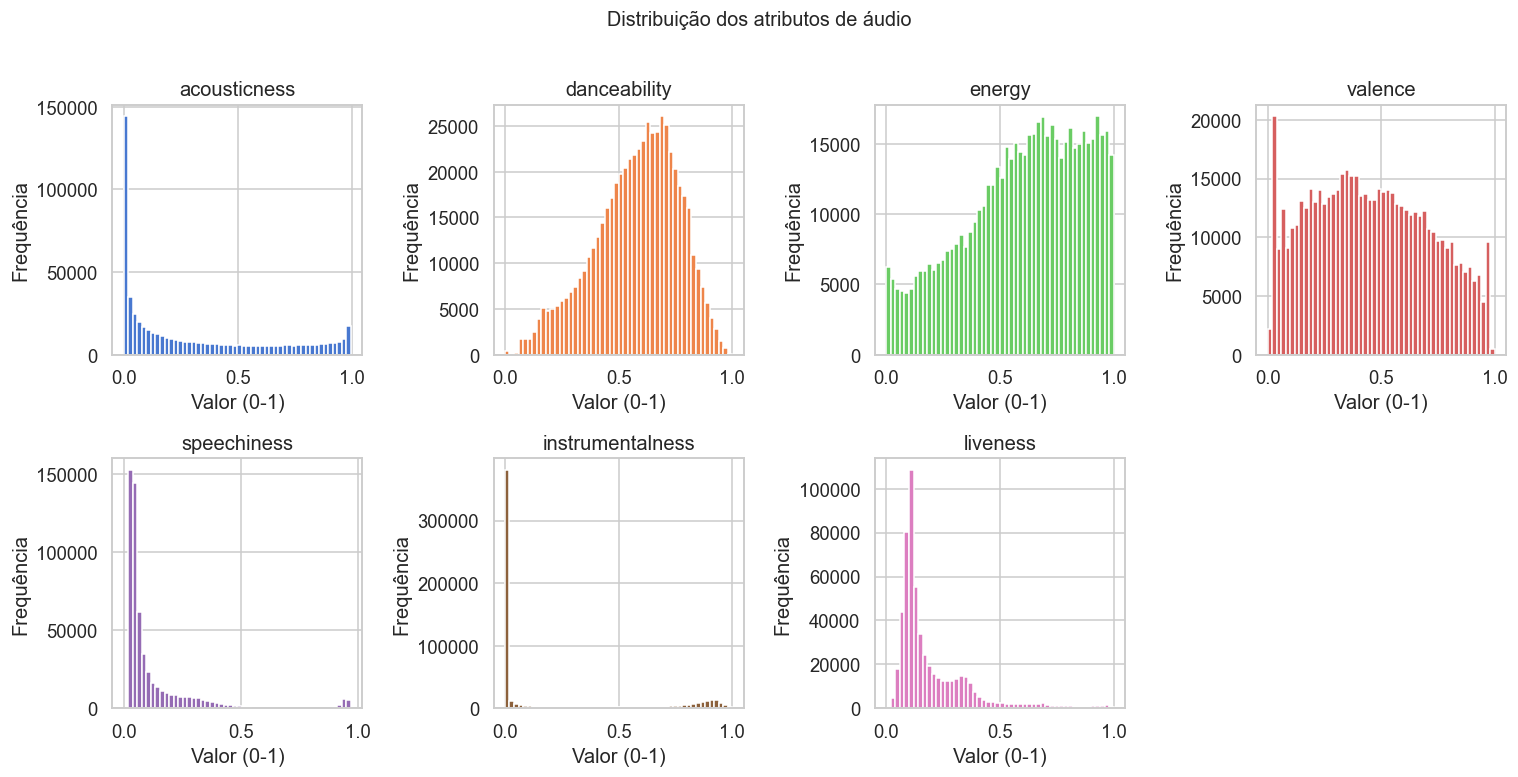

In [11]:
# Distribuições dos atributos de áudio (0-1)
n = len(AUDIO_COLS)
cols_per_row = 4
rows = (n + cols_per_row - 1) // cols_per_row
fig, axes = plt.subplots(rows, cols_per_row, figsize=(14, 3.5 * rows))
axes = axes.flatten()

for i, col in enumerate(AUDIO_COLS):
    axes[i].hist(
        df[col].dropna(), bins=50, color=sns.color_palette("muted")[i % 8], edgecolor="white"
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("Valor (0-1)")
    axes[i].set_ylabel("Frequência")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribuição dos atributos de áudio", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

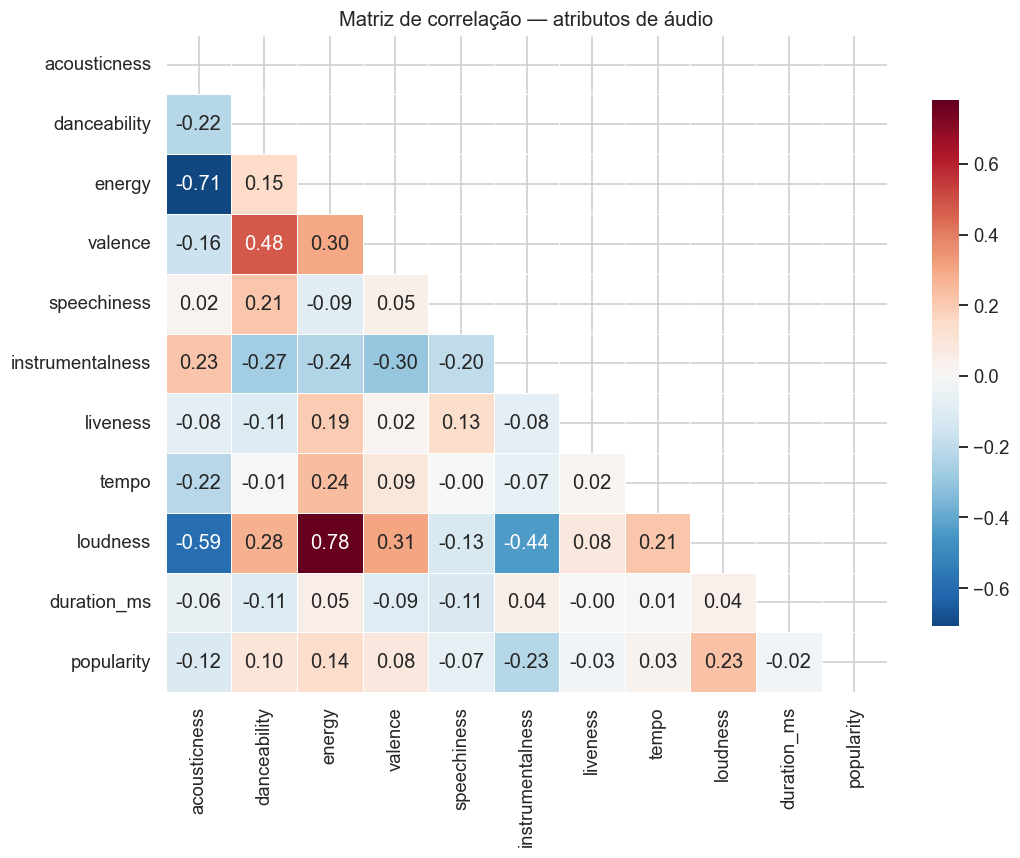

In [12]:
# Correlação entre atributos de áudio
all_num = AUDIO_COLS + [
    c for c in NUMERIC_COLS if c in df.columns and df[c].dtype in ["float64", "int64"]
]

fig, ax = plt.subplots(figsize=(10, 8))
corr = df[all_num].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Matriz de correlação — atributos de áudio")
plt.tight_layout()
plt.show()

## 6. Análise de popularidade

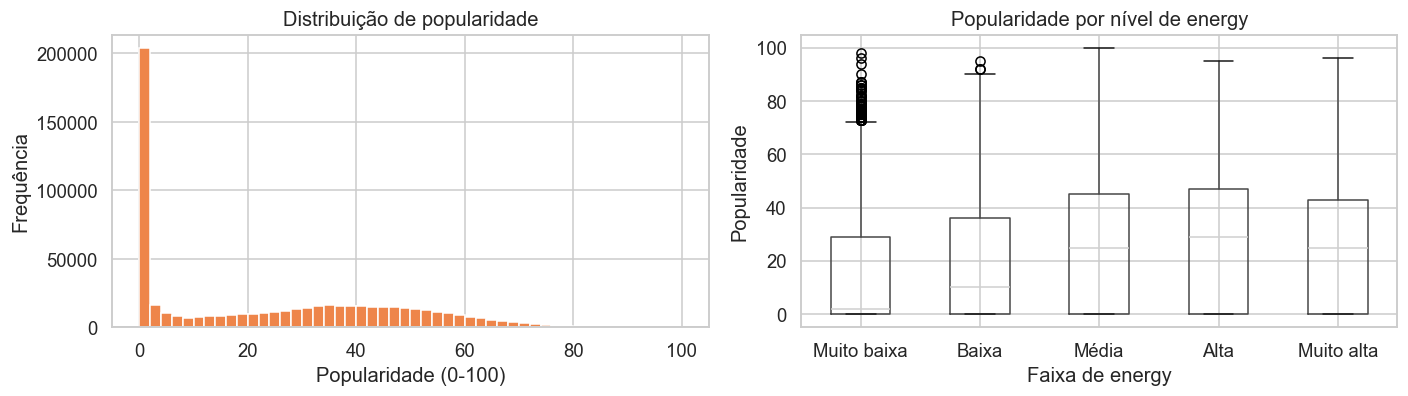


Popularidade - média: 23.4 | mediana: 21.0
Músicas com popularidade 0: 190,084 (32.0%)


In [13]:
if "popularity" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Distribuição de popularidade
    axes[0].hist(
        df["popularity"].dropna(), bins=50, color=sns.color_palette("muted")[1], edgecolor="white"
    )
    axes[0].set_title("Distribuição de popularidade")
    axes[0].set_xlabel("Popularidade (0-100)")
    axes[0].set_ylabel("Frequência")

    # Boxplot: popularidade por faixas de energy
    if "energy" in df.columns:
        df["energy_bin"] = pd.cut(
            df["energy"],
            bins=5,
            labels=["Muito baixa", "Baixa", "Média", "Alta", "Muito alta"],
        )
        df.boxplot(column="popularity", by="energy_bin", ax=axes[1])
        axes[1].set_title("Popularidade por nível de energy")
        axes[1].set_xlabel("Faixa de energy")
        axes[1].set_ylabel("Popularidade")
        plt.suptitle("")

    plt.tight_layout()
    plt.show()

    pop_mean = df["popularity"].mean()
    pop_median = df["popularity"].median()
    pop_zero = (df["popularity"] == 0).sum()

    print(f"\nPopularidade - média: {pop_mean:.1f} | mediana: {pop_median:.1f}")
    print(f"Músicas com popularidade 0: {pop_zero:,} ({pop_zero / len(df) * 100:.1f}%)")

In [14]:
# Top 10 músicas mais populares
if "popularity" in df.columns:
    cols_show = [
        c for c in ["track_name", "artist_name", "album_name", "popularity"] if c in df.columns
    ]
    print("Top 10 músicas mais populares:")
    top_songs = (
        df[cols_show]
        .sort_values("popularity", ascending=False)
        .drop_duplicates("track_name")
        .head(10)
        .reset_index(drop=True)
    )
    display(top_songs)

Top 10 músicas mais populares:


,track_name,artist_name,album_name,popularity
0,Die With A Smile,Lady Gaga,Die With A Smile,100
1,DtMF,Bad Bunny,DeBÍ TiRAR MáS FOToS,98
2,BIRDS OF A FEATHER,Billie Eilish,HIT ME HARD AND SOFT,98
3,That’s So True,Gracie Abrams,The Secret of Us (Deluxe),96
4,Not Like Us,Kendrick Lamar,Not Like Us,96
5,BAILE INoLVIDABLE,Bad Bunny,DeBÍ TiRAR MáS FOToS,96
6,WILDFLOWER,Billie Eilish,HIT ME HARD AND SOFT,95
7,APT.,ROSÉ,APT.,95
8,Sailor Song,Gigi Perez,Sailor Song,95
9,All The Stars (with SZA),SZA,Black Panther The Album Music From And Inspire...,95


## 7. Análise de tempo (tempo) e duração

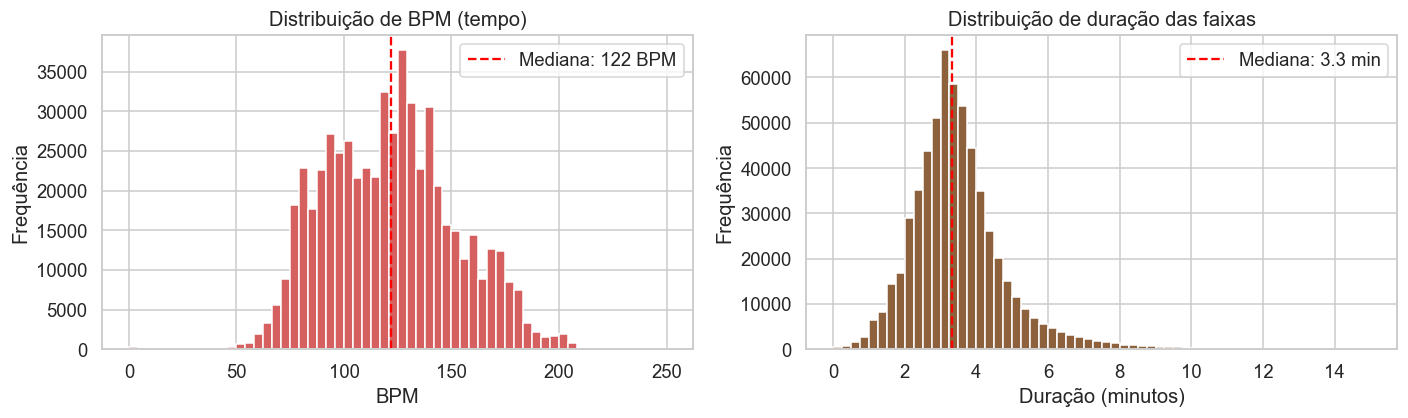

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribuição de BPM (tempo)
if "tempo" in df.columns:
    axes[0].hist(
        df["tempo"].dropna(), bins=60, color=sns.color_palette("muted")[3], edgecolor="white"
    )
    axes[0].set_title("Distribuição de BPM (tempo)")
    axes[0].set_xlabel("BPM")
    axes[0].set_ylabel("Frequência")
    tempo_median = df["tempo"].median()
    axes[0].axvline(
        tempo_median,
        color="red",
        linestyle="--",
        label=f"Mediana: {tempo_median:.0f} BPM",
    )
    axes[0].legend()
else:
    axes[0].set_visible(False)

# Distribuição de duração (em minutos)
if "duration_ms" in df.columns:
    dur_min = df["duration_ms"] / 60000
    dur_clipped = dur_min[dur_min < 15]  # ignora outliers
    axes[1].hist(dur_clipped, bins=60, color=sns.color_palette("muted")[5], edgecolor="white")
    axes[1].set_title("Distribuição de duração das faixas")
    axes[1].set_xlabel("Duração (minutos)")
    axes[1].set_ylabel("Frequência")
    axes[1].axvline(
        dur_clipped.median(),
        color="red",
        linestyle="--",
        label=f"Mediana: {dur_clipped.median():.1f} min",
    )
    axes[1].legend()
else:
    axes[1].set_visible(False)

plt.tight_layout()
plt.show()

## 8. Análise de gêneros musicais

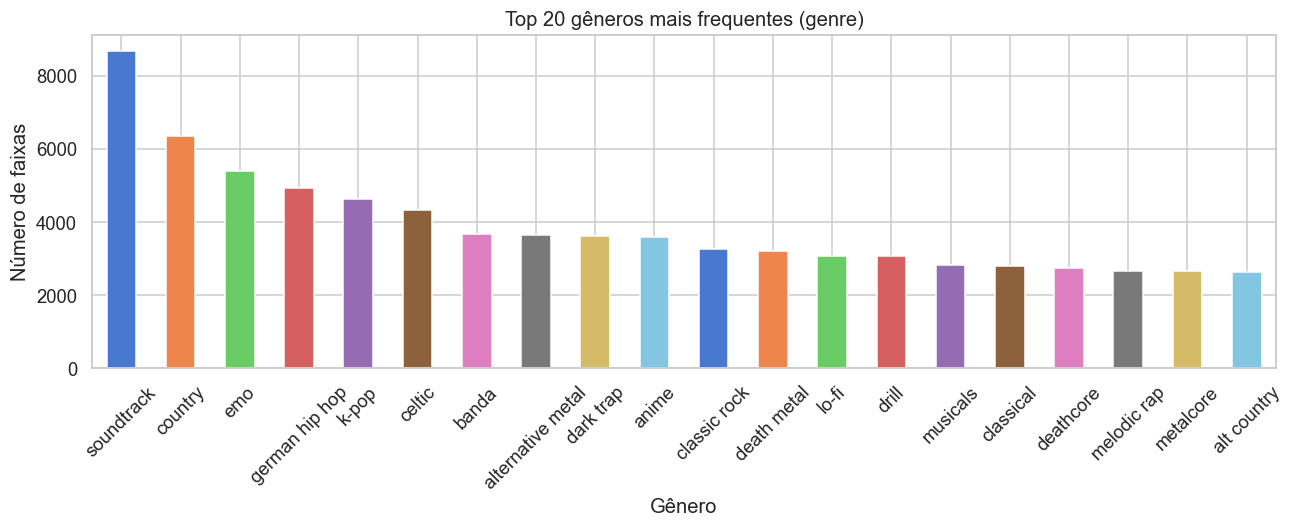

Total de gêneros únicos: 698


In [16]:
genre_col = next((c for c in ["track_genre", "genre"] if c in df.columns), None)

if genre_col:
    top_genres = df[genre_col].value_counts().head(20)
    fig, ax = plt.subplots(figsize=(12, 5))
    top_genres.plot(kind="bar", ax=ax, color=sns.color_palette("muted", 20))
    ax.set_title(f"Top 20 gêneros mais frequentes ({genre_col})")
    ax.set_xlabel("Gênero")
    ax.set_ylabel("Número de faixas")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
    print(f"Total de gêneros únicos: {df[genre_col].nunique()}")
else:
    print("Nenhuma coluna de gênero encontrada no dataset.")

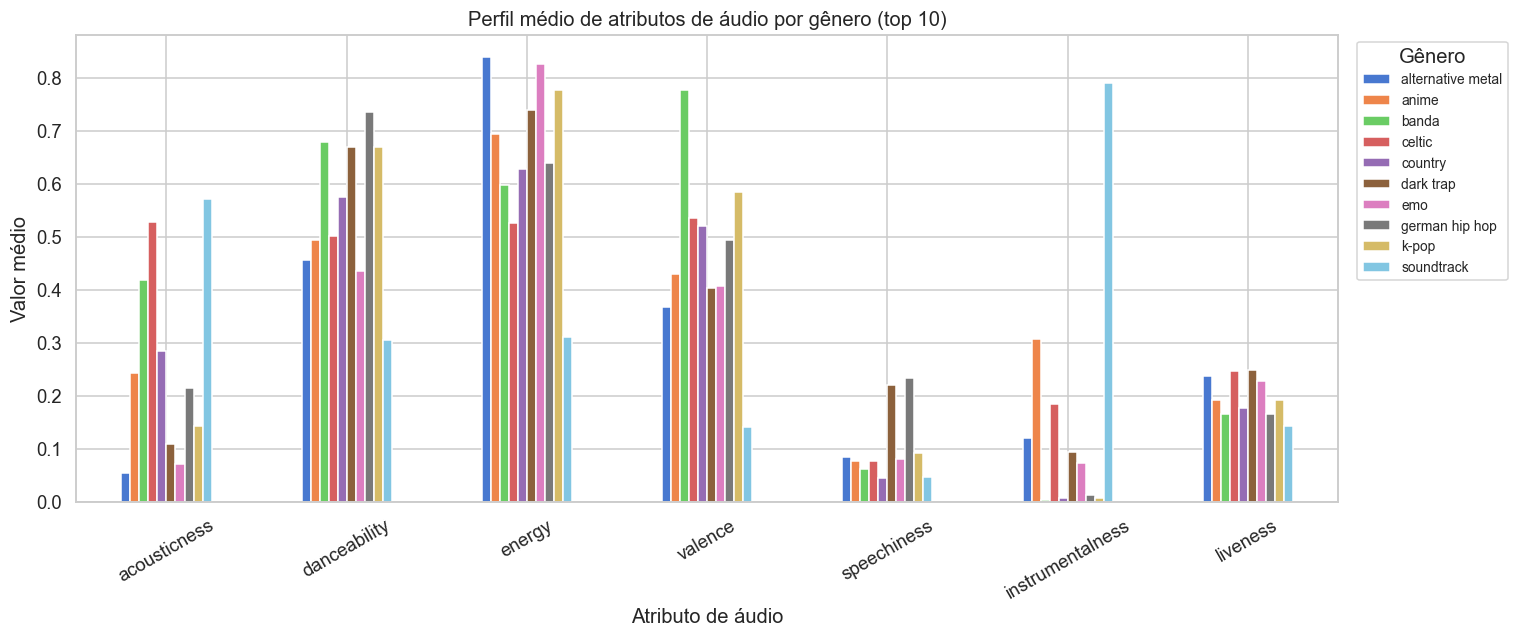

In [17]:
# Perfil médio dos atributos de áudio por gênero (top 10 gêneros)
if genre_col and AUDIO_COLS:
    top10_genres = df[genre_col].value_counts().head(10).index
    genre_profile = df[df[genre_col].isin(top10_genres)].groupby(genre_col)[AUDIO_COLS].mean()

    fig, ax = plt.subplots(figsize=(14, 6))
    genre_profile.T.plot(kind="bar", ax=ax)
    ax.set_title("Perfil médio de atributos de áudio por gênero (top 10)")
    ax.set_ylabel("Valor médio")
    ax.set_xlabel("Atributo de áudio")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="Gênero", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.show()

## 9. Scatter plots entre atributos relevantes

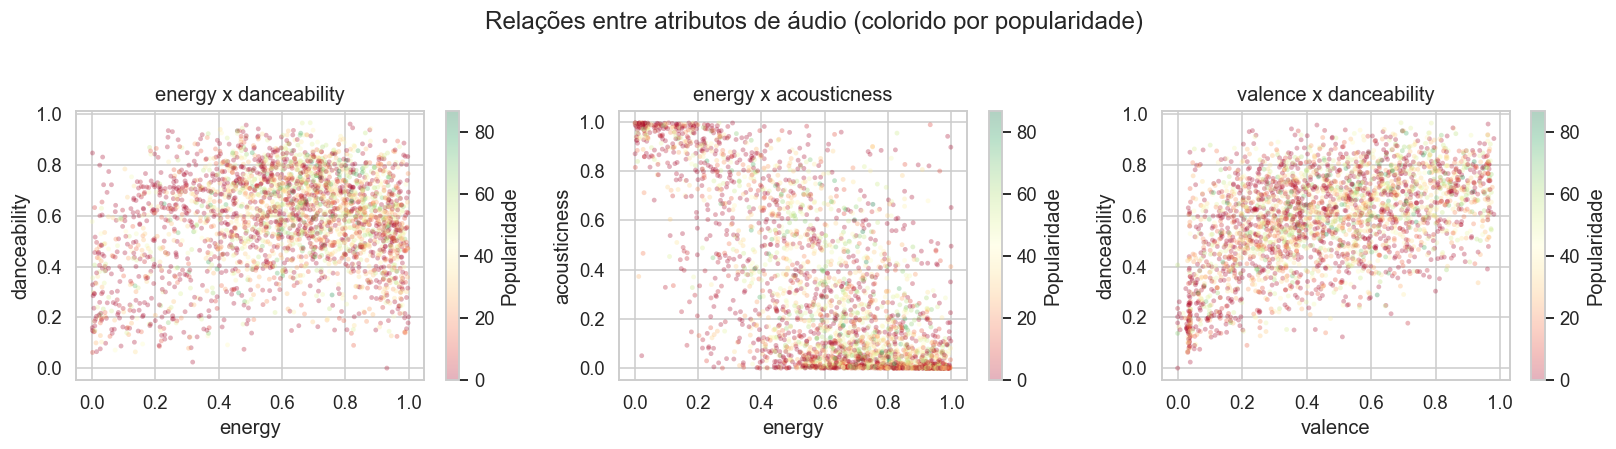

In [18]:
# Pares relevantes para o projeto de RI
pairs = [
    ("energy", "danceability"),
    ("energy", "acousticness"),
    ("valence", "danceability"),
]
pairs = [(a, b) for a, b in pairs if a in df.columns and b in df.columns]

if pairs:
    fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4))
    if len(pairs) == 1:
        axes = [axes]

    sample = df.sample(min(3000, len(df)), random_state=42)
    color_col = "popularity" if "popularity" in df.columns else None

    for ax, (x, y) in zip(axes, pairs, strict=True):
        scatter_kw = dict(alpha=0.3, s=10, edgecolors="none")
        if color_col:
            sc = ax.scatter(
                sample[x],
                sample[y],
                c=sample[color_col],
                cmap="RdYlGn",
                **scatter_kw,
            )
            plt.colorbar(sc, ax=ax, label="Popularidade")
        else:
            ax.scatter(sample[x], sample[y], **scatter_kw)
        ax.set_xlabel(x)
        ax.set_ylabel(y)
        ax.set_title(f"{x} x {y}")

    plt.suptitle(
        "Relações entre atributos de áudio (colorido por popularidade)",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum par relevante disponível para plot.")

## 10. Identificação de outliers e valores problemáticos

In [19]:
print("=== Verificação de valores fora do intervalo esperado ===\n")

# Atributos de áudio devem estar entre 0 e 1
for col in AUDIO_COLS:
    out_range = ((df[col] < 0) | (df[col] > 1)).sum()
    if out_range > 0:
        print(f"  {col}: {out_range} valores fora de [0, 1]")
    else:
        print(f"  {col}: OK (todos em [0, 1])")

# Popularidade deve estar entre 0 e 100
if "popularity" in df.columns:
    out_pop = ((df["popularity"] < 0) | (df["popularity"] > 100)).sum()
    print(f"  popularity: {out_pop} valores fora de [0, 100]")

# Tempo (BPM) — outliers extremos
if "tempo" in df.columns:
    extreme_bpm = ((df["tempo"] < 30) | (df["tempo"] > 300)).sum()
    print(f"  tempo: {extreme_bpm} valores fora de [30, 300] BPM")

=== Verificação de valores fora do intervalo esperado ===

  acousticness: OK (todos em [0, 1])
  danceability: OK (todos em [0, 1])
  energy: OK (todos em [0, 1])
  valence: OK (todos em [0, 1])
  speechiness: OK (todos em [0, 1])
  instrumentalness: OK (todos em [0, 1])
  liveness: OK (todos em [0, 1])
  popularity: 0 valores fora de [0, 100]
  tempo: 360 valores fora de [30, 300] BPM


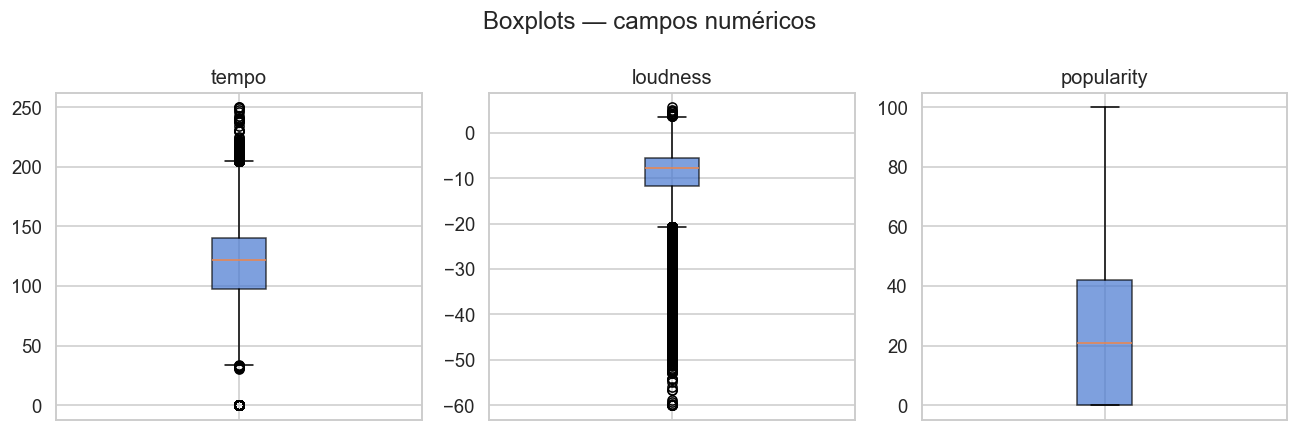

In [20]:
# Boxplots para detectar outliers nos campos numéricos
numeric_for_box = [c for c in ["tempo", "loudness", "popularity"] if c in df.columns]

if numeric_for_box:
    fig, axes = plt.subplots(
        1,
        len(numeric_for_box),
        figsize=(4 * len(numeric_for_box), 4),
    )
    if len(numeric_for_box) == 1:
        axes = [axes]
    for ax, col in zip(axes, numeric_for_box, strict=True):
        ax.boxplot(
            df[col].dropna(),
            patch_artist=True,
            boxprops=dict(facecolor=sns.color_palette("muted")[0], alpha=0.7),
        )
        ax.set_title(col)
        ax.set_xticklabels([])
    plt.suptitle("Boxplots — campos numéricos")
    plt.tight_layout()
    plt.show()

## Extra: Leitura alternativa via Parquet

O dataset também está disponível em formato Parquet (`tracks.parquet`, ~256M registros).
Para datasets grandes demais para pandas, usar DuckDB:

```python
import duckdb
duckdb.sql("SELECT count(*) FROM '../data/spotify-metadata/tracks.parquet'")
```

> **Nota:** o arquivo Parquet completo tem ~256 milhões de linhas e pode causar erros de memória com `pd.read_parquet()`. Prefira DuckDB ou leitura em chunks.

## 11. Resumo e decisões para a limpeza

In [21]:
print("=" * 60)
print("RESUMO DA EDA — DECISÕES PARA A PARTE 1 (BM25)")
print("=" * 60)

total = len(df)

print("\n1. TAMANHO DO DATASET")
print(f"   Total de registros: {total:,}")
print(f"   Total de colunas  : {df.shape[1]}")

print("\n2. PROBLEMAS IDENTIFICADOS")
print(f"   Duplicatas totais : {df.duplicated().sum():,}")
for col in TEXT_COLS:
    n = df[col].isnull().sum()
    if n > 0:
        print(f"   Nulos em {col:<20}: {n:,} ({n / total * 100:.2f}%)")
for col in AUDIO_COLS:
    n = df[col].isnull().sum()
    if n > 0:
        print(f"   Nulos em {col:<20}: {n:,} ({n / total * 100:.2f}%)")

print("\n3. COLUNAS PARA O CAMPO BM25 (text_field)")
print(f"   {' + '.join(TEXT_COLS)}")

print("\n4. FEATURES NUMÉRICAS PARA AS PARTES 2 E 3")
print(f"   {AUDIO_COLS + [c for c in NUMERIC_COLS if c in df.columns]}")

print("\n5. PRÓXIMOS PASSOS")
print("   [x] Remover duplicatas")
print("   [x] Tratar nulos nos campos textuais (preencher com string vazia)")
print("   [x] Normalizar strings (lowercase, strip, encoding UTF-8)")
print(f"   [x] Criar coluna text_field = {' + '.join(TEXT_COLS)}")
print("   [x] Exportar songs_clean.csv")
print("=" * 60)

RESUMO DA EDA — DECISÕES PARA A PARTE 1 (BM25)

1. TAMANHO DO DATASET
   Total de registros: 593,352
   Total de colunas  : 22

2. PROBLEMAS IDENTIFICADOS
   Duplicatas totais : 0
   Nulos em genre               : 243,901 (41.11%)
   Nulos em acousticness        : 24,583 (4.14%)
   Nulos em danceability        : 24,583 (4.14%)
   Nulos em energy              : 24,583 (4.14%)
   Nulos em valence             : 24,583 (4.14%)
   Nulos em speechiness         : 24,583 (4.14%)
   Nulos em instrumentalness    : 24,583 (4.14%)
   Nulos em liveness            : 24,583 (4.14%)

3. COLUNAS PARA O CAMPO BM25 (text_field)
   track_name + artist_name + album_name + genre

4. FEATURES NUMÉRICAS PARA AS PARTES 2 E 3
   ['acousticness', 'danceability', 'energy', 'valence', 'speechiness', 'instrumentalness', 'liveness', 'tempo', 'loudness', 'duration_ms', 'popularity', 'key', 'mode', 'time_signature']

5. PRÓXIMOS PASSOS
   [x] Remover duplicatas
   [x] Tratar nulos nos campos textuais (preencher com st

In [22]:
# Exportar relatório de metadados para o grupo
meta = pd.DataFrame(
    {
        "coluna": df.columns,
        "tipo": df.dtypes.values,
        "nulos": df.isnull().sum().values,
        "nulos_%": (df.isnull().sum().values / total * 100).round(2),
        "únicos": df.nunique().values,
        "min": df.min(numeric_only=True).reindex(df.columns).values,
        "max": df.max(numeric_only=True).reindex(df.columns).values,
        "média": df.mean(numeric_only=True).reindex(df.columns).round(3).values,
    }
)
REPORT_PATH = DATASET_DIR / "relatorio_eda.csv"
meta.to_csv(REPORT_PATH, index=False)
print(f"Relatório salvo em: {REPORT_PATH}")

Relatório salvo em: ../data/spotify-metadata/relatorio_eda.csv
